<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:28px;
">
Problema de Orszag-Tang (Intento)
</h2>

</div>

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<p>
Como primer intento en Python, armé una versión básica del problema de Orszag–Tang para verificar que la malla y las condiciones iniciales coincidieran con las utilizadas en PLUTO.
</p>

<p>
En esta etapa todavía no se resolvía la evolución temporal completa del sistema MHD, pero sí se pudieron visualizar las distribuciones iniciales de densidad, presión, velocidad y campo magnético.
</p>

<p>
Este paso fue importante porque permitió comprobar que todas las condiciones iniciales estaban bien implementadas antes de pasar a una versión más completa del código.
</p>

</div>

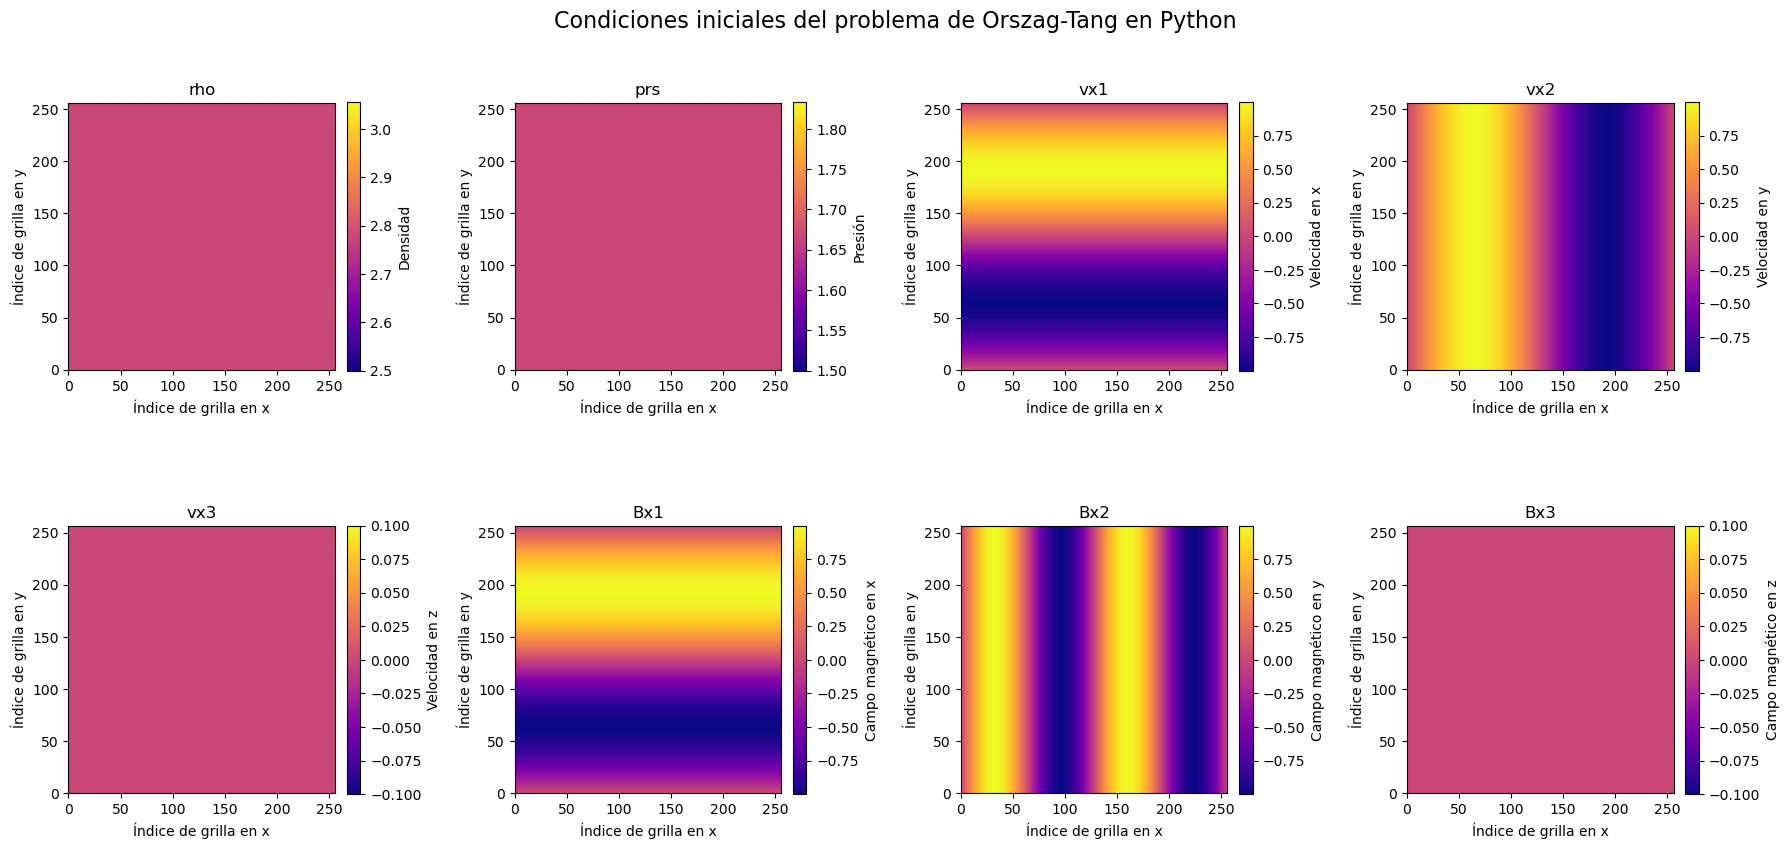

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#parametros

N = 256
Lx = 2 * np.pi
Ly = 2 * np.pi
gamma = 5 / 3
t_final = 3.10

dx = Lx / N
dy = Ly / N

x = np.linspace(0, Lx, N)
y = np.linspace(0, Ly, N)
X, Y = np.meshgrid(x, y)


#condiciones iniciales en PLUTO

rho = (25 / 9) * np.ones((N, N))
prs = (5 / 3) * np.ones((N, N))

vx1 = -np.sin(Y)        # vx
vx2 =  np.sin(X)        # vy
vx3 = np.zeros((N, N))  # vz

Bx1 = -np.sin(Y)        # Bx
Bx2 =  np.sin(2 * X)    # By
Bx3 = np.zeros((N, N))  # Bz


variables = [
    (rho, "rho", "Densidad"),
    (prs, "prs", "Presión"),
    (vx1, "vx1", "Velocidad en x"),
    (vx2, "vx2", "Velocidad en y"),
    (vx3, "vx3", "Velocidad en z"),
    (Bx1, "Bx1", "Campo magnético en x"),
    (Bx2, "Bx2", "Campo magnético en y"),
    (Bx3, "Bx3", "Campo magnético en z"),
]


#figura 

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for ax, (campo, nombre, titulo) in zip(axes, variables):
    im = ax.imshow(
        campo,
        cmap="plasma",
        origin="lower",
        extent=[0, N, 0, N],
        aspect="equal"
    )
    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel("Índice de grilla en x")
    ax.set_ylabel("Índice de grilla en y")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(titulo)

plt.suptitle("Condiciones iniciales del problema de Orszag-Tang en Python", fontsize=16)
plt.tight_layout()
plt.show()

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<p>
Sin embargo, esta implementación todavía era una versión bastante preliminar. Aunque permitía verificar las condiciones iniciales, aún no incorporaba el esquema completo de evolución magnetohidrodinámica ni las técnicas numéricas necesarias para mantener correctamente la condición <code>∇·B = 0</code>.
</p>

<p>
Por esta razón, los resultados obtenidos en esta etapa no reproducían la dinámica compleja del problema de Orszag–Tang. Fue necesario desarrollar una versión más completa del solver para capturar adecuadamente la evolución temporal del sistema y obtener resultados comparables con los generados por PLUTO.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<p>
Como paso intermedio, desarrollé una versión del problema de Orszag–Tang en Python que ya incluía la evolución temporal del sistema MHD mediante un esquema numérico tipo Rusanov, aunque todavía sin implementar <i>constrained transport</i>.
</p>

<p>
Esta versión permitió avanzar más allá de la simple verificación de las condiciones iniciales, ya que resolvía la evolución temporal de la densidad, la presión, la velocidad y el campo magnético.
</p>

<p>
Sin embargo, al no contar aún con un método específico para preservar la condición <code>∇·B = 0</code>, la solución presentaba limitaciones numéricas y una menor estabilidad en comparación con la versión final desarrollada posteriormente.
</p>

</div>

Tiempo final alcanzado: t = 3.10
Promedio de |divB| = 2.633548e-02


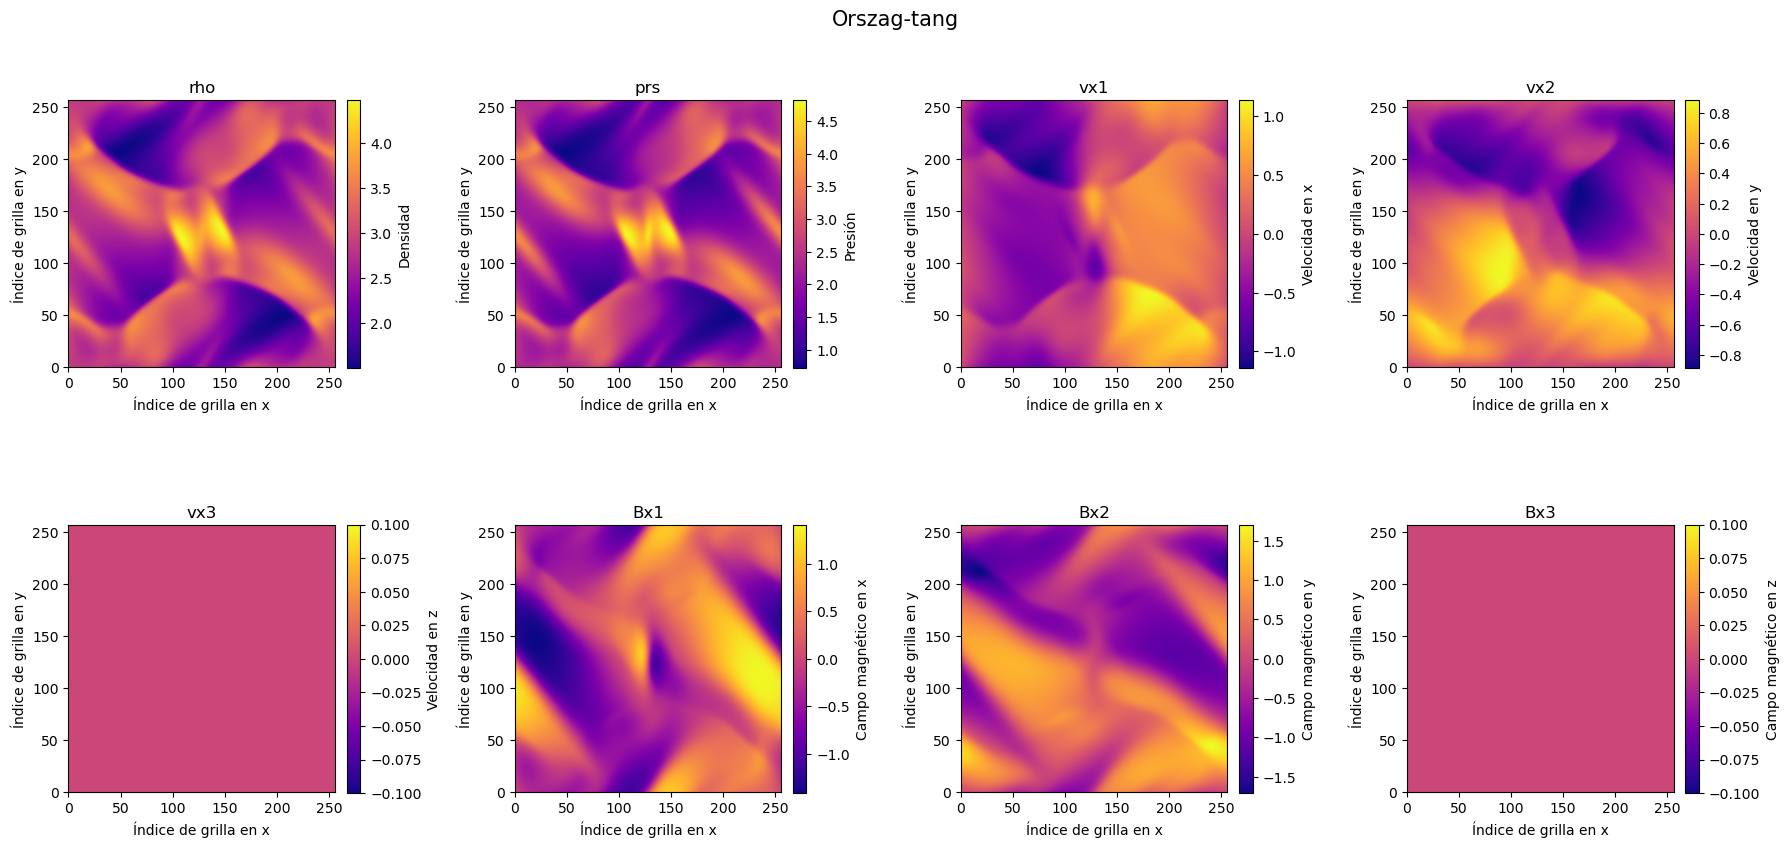

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#aquí una versión intermedia del problema de Orszag-Tang
#sin constrained transport. Sí evoluciona en el tiempo, pero
#al no controlar div(B)=0 de forma especial, no es tan buena
#como la versión final que sí usa constrained transport.



# parámetros 
N = 256
boxsize = 2 * np.pi
gamma = 5 / 3
courant_fac = 0.3
t = 0.0
tEnd = 3.10

dx = boxsize / N
dy = dx


#malla del dominio

x = (np.arange(N) + 0.5) * dx
y = (np.arange(N) + 0.5) * dy
X, Y = np.meshgrid(x, y, indexing="ij")


#condiciones iniciales PLUTO
rho = (25 / 9) * np.ones((N, N))
pgas = (5 / 3) * np.ones((N, N))

vx = -np.sin(Y)
vy = np.sin(X)

Bx = -np.sin(Y)
By = np.sin(2 * X)

vz = np.zeros_like(rho)
Bz = np.zeros_like(rho)


#variables conservadas
momx = rho * vx
momy = rho * vy

E = (
    pgas / (gamma - 1)
    + 0.5 * rho * (vx**2 + vy**2)
    + 0.5 * (Bx**2 + By**2)
)


#f. auxiliares

def primitive_from_conserved(rho, momx, momy, E, Bx, By, gamma):
    vx = momx / rho
    vy = momy / rho
    kinetic = 0.5 * rho * (vx**2 + vy**2)
    magnetic = 0.5 * (Bx**2 + By**2)
    pgas = (gamma - 1) * (E - kinetic - magnetic)

    # Yo pongo pisos numéricos para evitar valores no físicos.
    rho = np.maximum(rho, 1e-6)
    pgas = np.maximum(pgas, 1e-6)

    return rho, vx, vy, pgas


def fast_speed(rho, pgas, Bx, By, gamma, vn):
    a2 = gamma * pgas / rho
    b2 = (Bx**2 + By**2) / rho
    cf2 = 0.5 * (a2 + b2 + np.sqrt((a2 + b2) ** 2))
    return np.abs(vn) + np.sqrt(cf2)


def flux_x(rho, vx, vy, pgas, Bx, By, E):
    ptot = pgas + 0.5 * (Bx**2 + By**2)
    vdotB = vx * Bx + vy * By

    F_rho = rho * vx
    F_mx = rho * vx**2 + ptot - Bx**2
    F_my = rho * vx * vy - Bx * By
    F_E = (E + ptot) * vx - Bx * vdotB
    F_Bx = np.zeros_like(Bx)
    F_By = vx * By - vy * Bx

    return F_rho, F_mx, F_my, F_E, F_Bx, F_By


def flux_y(rho, vx, vy, pgas, Bx, By, E):
    ptot = pgas + 0.5 * (Bx**2 + By**2)
    vdotB = vx * Bx + vy * By

    G_rho = rho * vy
    G_mx = rho * vx * vy - Bx * By
    G_my = rho * vy**2 + ptot - By**2
    G_E = (E + ptot) * vy - By * vdotB
    G_Bx = vy * Bx - vx * By
    G_By = np.zeros_like(By)

    return G_rho, G_mx, G_my, G_E, G_Bx, G_By


def rusanov_flux_x(rho, momx, momy, E, Bx, By, gamma):
    rhoL = rho
    rhoR = np.roll(rho, -1, axis=0)

    momxL = momx
    momxR = np.roll(momx, -1, axis=0)

    momyL = momy
    momyR = np.roll(momy, -1, axis=0)

    EL = E
    ER = np.roll(E, -1, axis=0)

    BxL = Bx
    BxR = np.roll(Bx, -1, axis=0)

    ByL = By
    ByR = np.roll(By, -1, axis=0)

    rhoL, vxL, vyL, pL = primitive_from_conserved(rhoL, momxL, momyL, EL, BxL, ByL, gamma)
    rhoR, vxR, vyR, pR = primitive_from_conserved(rhoR, momxR, momyR, ER, BxR, ByR, gamma)

    FL = flux_x(rhoL, vxL, vyL, pL, BxL, ByL, EL)
    FR = flux_x(rhoR, vxR, vyR, pR, BxR, ByR, ER)

    sL = fast_speed(rhoL, pL, BxL, ByL, gamma, vxL)
    sR = fast_speed(rhoR, pR, BxR, ByR, gamma, vxR)
    smax = np.maximum(sL, sR)

    UL = [rhoL, momxL, momyL, EL, BxL, ByL]
    UR = [rhoR, momxR, momyR, ER, BxR, ByR]

    return [
        0.5 * (fL + fR) - 0.5 * smax * (uR - uL)
        for fL, fR, uL, uR in zip(FL, FR, UL, UR)
    ]


def rusanov_flux_y(rho, momx, momy, E, Bx, By, gamma):
    rhoL = rho
    rhoR = np.roll(rho, -1, axis=1)

    momxL = momx
    momxR = np.roll(momx, -1, axis=1)

    momyL = momy
    momyR = np.roll(momy, -1, axis=1)

    EL = E
    ER = np.roll(E, -1, axis=1)

    BxL = Bx
    BxR = np.roll(Bx, -1, axis=1)

    ByL = By
    ByR = np.roll(By, -1, axis=1)

    rhoL, vxL, vyL, pL = primitive_from_conserved(rhoL, momxL, momyL, EL, BxL, ByL, gamma)
    rhoR, vxR, vyR, pR = primitive_from_conserved(rhoR, momxR, momyR, ER, BxR, ByR, gamma)

    GL = flux_y(rhoL, vxL, vyL, pL, BxL, ByL, EL)
    GR = flux_y(rhoR, vxR, vyR, pR, BxR, ByR, ER)

    sL = fast_speed(rhoL, pL, BxL, ByL, gamma, vyL)
    sR = fast_speed(rhoR, pR, BxR, ByR, gamma, vyR)
    smax = np.maximum(sL, sR)

    UL = [rhoL, momxL, momyL, EL, BxL, ByL]
    UR = [rhoR, momxR, momyR, ER, BxR, ByR]

    return [
        0.5 * (gL + gR) - 0.5 * smax * (uR - uL)
        for gL, gR, uL, uR in zip(GL, GR, UL, UR)
    ]


def divB(Bx, By, dx, dy):
    dBx = (np.roll(Bx, -1, axis=0) - np.roll(Bx, 1, axis=0)) / (2 * dx)
    dBy = (np.roll(By, -1, axis=1) - np.roll(By, 1, axis=1)) / (2 * dy)
    return dBx + dBy



#evolución temporal
while t < tEnd:
    rho, vx, vy, pgas = primitive_from_conserved(rho, momx, momy, E, Bx, By, gamma)

    cf = fast_speed(rho, pgas, Bx, By, gamma, np.sqrt(vx**2 + vy**2))
    dt = courant_fac * np.min(dx / (cf + 1e-12))

    if t + dt > tEnd:
        dt = tEnd - t

    Fx = rusanov_flux_x(rho, momx, momy, E, Bx, By, gamma)
    Gy = rusanov_flux_y(rho, momx, momy, E, Bx, By, gamma)

    rho  = rho  - (dt / dx) * (Fx[0] - np.roll(Fx[0], 1, axis=0)) - (dt / dy) * (Gy[0] - np.roll(Gy[0], 1, axis=1))
    momx = momx - (dt / dx) * (Fx[1] - np.roll(Fx[1], 1, axis=0)) - (dt / dy) * (Gy[1] - np.roll(Gy[1], 1, axis=1))
    momy = momy - (dt / dx) * (Fx[2] - np.roll(Fx[2], 1, axis=0)) - (dt / dy) * (Gy[2] - np.roll(Gy[2], 1, axis=1))
    E    = E    - (dt / dx) * (Fx[3] - np.roll(Fx[3], 1, axis=0)) - (dt / dy) * (Gy[3] - np.roll(Gy[3], 1, axis=1))
    Bx   = Bx   - (dt / dx) * (Fx[4] - np.roll(Fx[4], 1, axis=0)) - (dt / dy) * (Gy[4] - np.roll(Gy[4], 1, axis=1))
    By   = By   - (dt / dx) * (Fx[5] - np.roll(Fx[5], 1, axis=0)) - (dt / dy) * (Gy[5] - np.roll(Gy[5], 1, axis=1))

    rho = np.maximum(rho, 1e-6)

    t += dt


rho, vx, vy, pgas = primitive_from_conserved(rho, momx, momy, E, Bx, By, gamma)
vz = np.zeros_like(rho)
Bz = np.zeros_like(rho)

divB_final = divB(Bx, By, dx, dy)

print(f"Tiempo final alcanzado: t = {t:.2f}")
print(f"Promedio de |divB| = {np.mean(np.abs(divB_final)):.6e}")


#figura
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

variables = [
    (rho, "rho", "Densidad"),
    (pgas, "prs", "Presión"),
    (vx, "vx1", "Velocidad en x"),
    (vy, "vx2", "Velocidad en y"),
    (vz, "vx3", "Velocidad en z"),
    (Bx, "Bx1", "Campo magnético en x"),
    (By, "Bx2", "Campo magnético en y"),
    (Bz, "Bx3", "Campo magnético en z"),
]

for ax, (campo, nombre, etiqueta) in zip(axes, variables):
    im = ax.imshow(
        campo,
        cmap="plasma",
        origin="lower",
        extent=[0, 256, 0, 256],
        aspect="equal"
    )
    ax.set_title(nombre)
    ax.set_xlabel("Índice de grilla en x")
    ax.set_ylabel("Índice de grilla en y")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(etiqueta)

plt.suptitle("Orszag-tang", fontsize=15)
plt.tight_layout()
plt.show()

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<p>
En esta etapa logré construir una versión más avanzada que la simple definición de condiciones iniciales, porque el código ya evolucionaba en el tiempo las variables principales del sistema. Sin embargo, yo misma veía que todavía no alcanzaba el comportamiento esperado, sobre todo porque aún no había incorporado un tratamiento adecuado para conservar la condición ∇·B = 0 en el campo magnético. Por eso, aunque esta versión representó un avance importante dentro del proceso, todavía no me permitía reproducir con la misma fidelidad los resultados de referencia.
</p>

<p>
Además, el tiempo que exige desarrollar, revisar y depurar un solver MHD de este tipo fue considerable, de modo que esta implementación quedó como una etapa intermedia de aprendizaje antes de llegar a una versión más robusta.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<p>
No es mucho, pero es trabajo honesto.
</p>

</div>